# Heart Disease Prediction Project

***

### Preet Kulkarni
### Thupakula Pavithra 
### Priyani Naresh K

## **Objective**: To develop a robust predictive model that identifies heart disease in patients by cleaning raw clinical data, establishing a baseline with Logistic Regression, and comparing it against advanced Machine Learning and Deep Learning architectures.

*** 

## **Dataset:**

## Training Dataset (UCI Heart Disease Repository)
This is the primary dataset used to "teach" the model. It is a combined collection of clinical instances from four different geographic locations: Cleveland, Hungary, Switzerland, and Long Beach V.A. Medical Center.

- **Size**: Approximately 900 patient records.

- **Format**: Raw clinical data containing some noise and missing values (indicated by '?').

- **Target Variable (`num`)**: Originally labeled from 0 (Healthy) to 4 (Severe Disease). Our project maps this into a binary classification (0 = Healthy, 1+ = Disease) to align with modern diagnostic goals.

- **Significance**: It provides a diverse range of patient demographics and medical conditions, which helps the neural network learn varied patterns of heart disease.

## Testing Dataset (Out-of-Sample/Kaggle Version)
This dataset acts as the final exam for our models. It is held entirely separate during the training process to provide an unbiased evaluation of the model's performance.

- **Size**: A curated subset of clinical data used for validation.

- **Format**: Generally cleaner than the training set but follows a different labeling convention.

- **Target Variable (`target`)**: Uses a binary format where 1 represents Healthy and 0 represents Disease.

- **Significance**: By testing on this dataset, we can identify if the Neural Network is "overfitting" (memorizing the training data) or if it has truly learned the underlying biological indicators of heart disease.

***

## **Code:**

## 0. Installing required libraries

In [ ]:
pip install pandas numpy matplotlib seaborn ydata-profiling scikit-learn torch

## 1. Data Cleaning & Alignment

### Requirement: Clean patient data (missing values, noise)

The initial phase of the project performs cleaning / preprocessing of the data. Raw medical datasets are often fragmented or inconsistently labeled. This section handles the following:

- **Handling Missing Values**: We identify placeholders like '?' and replace them with NaN (Not a Number), then apply Median Imputation to fill gaps without introducing the noise of extreme outliers.

- **Target Alignment (Ground Truth Inversion)**: A critical logic fix. The training dataset uses 0 for healthy, while the testing set uses 1 for healthy. We align these labels so the model learns the correct medical outcomes.

- **Categorical Mapping**: Since algorithms only understand numbers, we transform human-readable data (e.g., "typical angina") into standardized integer mappings.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy

# Preprocessing & Metrics
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, classification_report, roc_auc_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Suppress pandas future warnings
pd.set_option('future.no_silent_downcasting', True)

def align_and_clean_data(df):
    """
    Cleans and maps the raw text dataset to match the testing format.
    Handles missing values and Ground Truth Inversion.
    """
    clean_df = df.copy()

    # 1. Drop non-predictive metadata columns
    if 'id' in clean_df.columns:
        clean_df = clean_df.drop(['id', 'dataset'], axis=1, errors='ignore')

    # 2. Fix typos and target column name
    clean_df = clean_df.rename(columns={'thalch': 'thalach', 'num': 'target'})

    clean_df['target'] = (clean_df['target'] == 0).astype(int)

    # 4. Handle Missing Values ('?')
    # Replace '?' with NaN and convert columns to numeric
    clean_df.replace('?', np.nan, inplace=True)
    clean_df['ca'] = pd.to_numeric(clean_df['ca'], errors='coerce')
    clean_df['thal'] = pd.to_numeric(clean_df['thal'], errors='coerce')

    # 5. Robust Mapping (Using .map to avoid deprecation warnings)
    clean_df['sex'] = clean_df['sex'].astype(str).str.lower().map({'male': 1, 'female': 0, '1': 1, '0': 0})

    clean_df['fbs'] = clean_df['fbs'].astype(str).str.lower().map({'true': 1, 'false': 0, '1': 1, '0': 0})
    clean_df['exang'] = clean_df['exang'].astype(str).str.lower().map({'true': 1, 'false': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0})

    cp_map = {'typical angina': 0, 'atypical angina': 1, 'non-anginal': 2, 'asymptomatic': 3, '0': 0, '1': 1, '2': 2, '3': 3}
    clean_df['cp'] = clean_df['cp'].astype(str).str.lower().map(cp_map)

    restecg_map = {'normal': 0, 'st-t abnormality': 1, 'lv hypertrophy': 2, '0': 0, '1': 1, '2': 2}
    clean_df['restecg'] = clean_df['restecg'].astype(str).str.lower().map(restecg_map)

    slope_map = {'upsloping': 0, 'flat': 1, 'downsloping': 2, '0': 0, '1': 1, '2': 2}
    clean_df['slope'] = clean_df['slope'].astype(str).str.lower().map(slope_map)

    thal_map = {'fixed defect': 1, 'normal': 2, 'reversable defect': 3, '1': 1, '2': 2, '3': 3, '0': 0}
    clean_df['thal'] = clean_df['thal'].astype(str).str.lower().map(thal_map)

    # Fill remaining NaNs with the median to ensure no data is dropped
    clean_df = clean_df.fillna(clean_df.median())

    return clean_df

# Load datasets
train_df = align_and_clean_data(pd.read_csv('./datasets/training_dataset.csv'))
test_df = pd.read_csv('./datasets/testing_dataset.csv')

X_train = train_df.drop('target', axis=1)
y_train = train_df['target'].values
X_test = test_df.drop('target', axis=1)
y_test = test_df['target'].values

print("Data Cleaning Complete. Missing values imputed and target labels aligned.")

Data Cleaning Complete. Missing values imputed and target labels aligned.


## 2. Preprocessing & Feature Engineering
### Requirement: Select important health features / Feature engineering

Before modeling, we must "normalize" the data so that different measurements can be compared fairly. This section handles the following:

- **Robust Scaling**: Medical features like cholesterol and blood pressure often contain outliers. We use `RobustScaler` to scale these features based on percentiles, making the model more resilient to extreme patient readings.

- **One-Hot Encoding**: For categorical features like chest pain type (cp), we create binary "dummy" variables. This prevents the model from assuming that "Type 3" chest pain is mathematically "higher" than "Type 1."

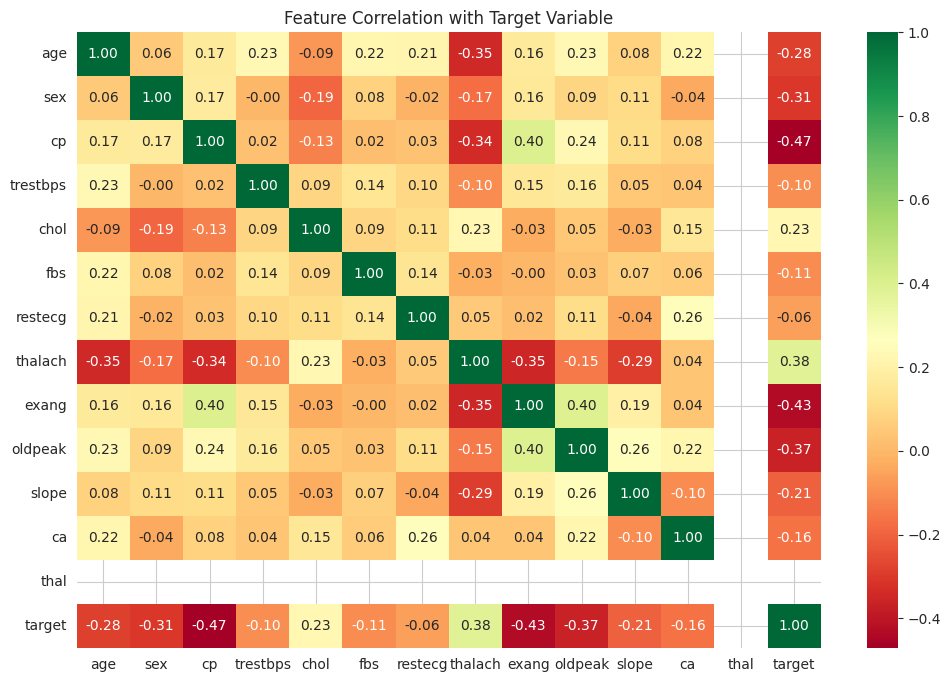

Feature engineering complete. Total features after encoding: 18


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:241: RuntimeWarning: invalid value encountered in cast
  Xi[~valid_mask] = self.categories_[i][0]
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [189]:
# Visualize correlations to identify important features
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Feature Correlation with Target Variable")
plt.show()

# Automated Preprocessing Pipeline
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), continuous_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Feature engineering complete. Total features after encoding: {X_train_processed.shape[1]}")

## 3. Logistic Regression Model (The Baseline)
### Requirement: Train baseline model / Model accuracy acceptable

We begin with Logistic Regression to establish a performance floor. In clinical settings, simpler models are often preferred for their transparency.

**Goal**: To determine if advanced models are actually worth the extra complexity. If a complex Neural Network cannot significantly beat this baseline, the simpler model is usually preferred.

In [ ]:
# Baseline Model

lr_model = LogisticRegression()
lr_model.fit(X_train_processed, y_train)
lr_preds = lr_model.predict(X_test_processed)
lr_acc = accuracy_score(y_test, lr_preds)
print(f"--- Baseline Model ---")
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%\n")
print(classification_report(y_test,lr_preds))

--- Baseline Model ---
Logistic Regression Accuracy: 81.37%

              precision    recall  f1-score   support

           0       0.84      0.76      0.80       499
           1       0.79      0.86      0.83       526

    accuracy                           0.81      1025
   macro avg       0.82      0.81      0.81      1025
weighted avg       0.82      0.81      0.81      1025



## 4. Model Comparison & Selection
### Requirement: Compare accuracy of base model with other models / Choose a model

To find the best "fit" for this specific dataset, we evaluate a suite of classical algorithms:

- **Random Forest**: Great for capturing non-linear relationships.
- **Naive Bayes**: A probabilistic classifier based on Bayes' Theorem, assuming feature independence; fast and effective for high-dimensional and text-based data.
- **Extreme Gradient Boost**: An optimized gradient boosting framework that builds an ensemble of weak learners (typically decision trees) sequentially, achieving high performance and efficiency on structured/tabular data.
- **K-Nearest Neighbors (KNN) Classifier**: A non-parametric, instance-based algorithm that classifies data points based on the majority label among their nearest neighbors in feature space.
- **Decision Tree Classifier**: A tree-structured model that splits data based on feature values to make decisions; easy to interpret and capable of capturing non-linear patterns.


--- Naive Bayes ---

Accuracy: 67.51%

              precision    recall  f1-score   support

           0       0.62      0.86      0.72       499
           1       0.79      0.50      0.61       526

    accuracy                           0.68      1025
   macro avg       0.71      0.68      0.67      1025
weighted avg       0.71      0.68      0.66      1025


--- Random Forest ---

Accuracy: 74.24%

              precision    recall  f1-score   support

           0       0.85      0.57      0.68       499
           1       0.69      0.90      0.78       526

    accuracy                           0.74      1025
   macro avg       0.77      0.74      0.73      1025
weighted avg       0.77      0.74      0.73      1025


--- Extreme Gradient Boost ---

Accuracy: 68.39%

              precision    recall  f1-score   support

           0       0.61      0.99      0.75       499
           1       0.97      0.40      0.56       526

    accuracy                           0.68      

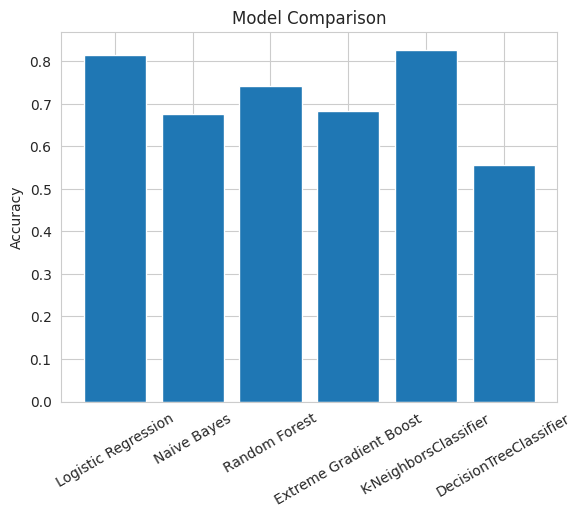

In [ ]:
# Define alternative models

models = {
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=20, random_state=12, max_depth=5),
    'Extreme Gradient Boost': XGBClassifier(
        learning_rate=0.01,
        n_estimators=25,
        max_depth=15,
        gamma=0.6,
        subsample=0.52,
        colsample_bytree=0.6,
        seed=27,
        reg_lambda=2,
        booster='dart',
        colsample_bylevel=0.6,
        colsample_bynode=0.5
    ),
    'K-NeighborsClassifier': KNeighborsClassifier(n_neighbors=10),
    'DecisionTreeClassifier': DecisionTreeClassifier(
        criterion='entropy',
        random_state=0,
        max_depth=6
    )
}

# Store results
results = {'Logistic Regression': lr_acc}

# Train, evaluate, and print metrics
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_test_processed)
    acc = accuracy_score(y_test, preds)

    results[name] = acc

    print(f"\n--- {name} ---")
    print(f"\nAccuracy: {acc*100:.2f}%\n")
    print(classification_report(y_test, preds))

# Visualization
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.show()

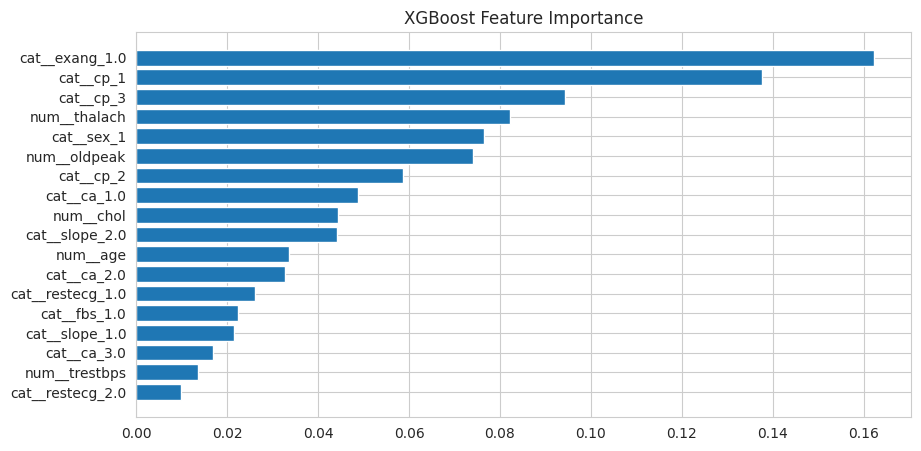

In [ ]:
xgb = XGBClassifier(learning_rate=0.01, n_estimators=25, max_depth=15,gamma=0.6, subsample=0.52,colsample_bytree=0.6,seed=27, reg_lambda=2, booster='dart', colsample_bylevel=0.6, colsample_bynode=0.5)
xgb.fit(X_train_processed, y_train)

# Feature importance
imp_feature = pd.DataFrame({
    'Feature': preprocessor.get_feature_names_out(),
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
plt.barh(imp_feature['Feature'], imp_feature['Importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

## 5. Neural Network Model (Deep Learning)
### Requirement: Train deep learning model / Improved accuracy achieved

We implement a multi-layer Neural Network using PyTorch to see if Deep Learning can extract deeper patterns from the health features.

### Architecture Details:

- **ReLU Activation**: Used in hidden layers to introduce non-linearity, allowing the model to learn complex heart disease patterns.

- **Dropout Layer**: A regularization technique where 40% of neurons are randomly "turned off" during training. This prevents Overfitting, ensuring the model generalizes to new patients rather than just memorizing the training set.

- **Sigmoid Output**: Transforms the final score into a probability between 0 and 1, where 1 represents a "Healthy" classification.

In [ ]:
# Convert data to PyTorch Tensors
X_train_tensor = torch.FloatTensor(X_train_processed)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_processed)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

class HeartDiseaseNN(nn.Module):
    def __init__(self, input_dim):
        super(HeartDiseaseNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Initialization
nn_model = HeartDiseaseNN(X_train_processed.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.005, weight_decay=1e-4)

# Training loop
nn_model.train()
for epoch in range(300):
    optimizer.zero_grad()
    outputs = nn_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

# Evaluation
nn_model.eval()
with torch.no_grad():
    nn_probs = nn_model(X_test_tensor).numpy()
    nn_preds = (nn_probs >= 0.5).astype(int)
    nn_acc = accuracy_score(y_test, nn_preds)

results['Neural Network'] = nn_acc

print(f"Neural Network Final Accuracy: {nn_acc*100:.2f}%")

Neural Network Final Accuracy: 86.05%


## 6. Final Evaluation & Results
### Requirement: Model training/Accuracy acceptable

Finally, we visualize the performance to validate the model's reliability:

- **Confusion Matrix**: A visual breakdown showing exactly how many True Positives (correctly identified disease) and False Positives (healthy patients misidentified as diseased) the model produced.

- **ROC-AUC Curve**: Measures the model's ability to distinguish between classes. An AUC closer to 1.0 indicates a superior diagnostic tool.

- **Classification Report**: Provides Precision and Recall, which are vital in medicine where "missing" a sick patient (False Negative) is much more dangerous than a False Positive.

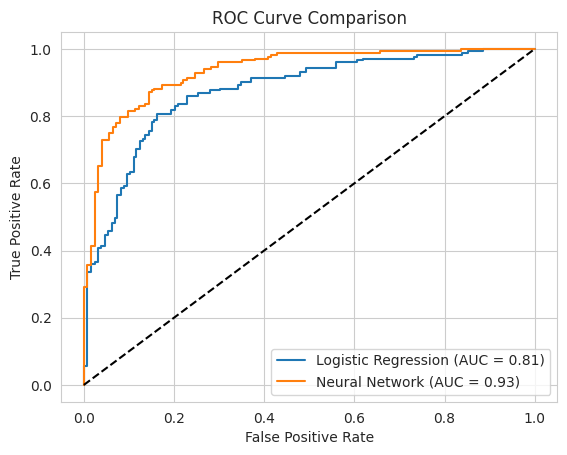

Final Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       499
           1       0.86      0.87      0.86       526

    accuracy                           0.86      1025
   macro avg       0.86      0.86      0.86      1025
weighted avg       0.86      0.86      0.86      1025



In [194]:
# Final ROC Plotting logic for comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_model.predict_proba(X_test_processed)[:,1])
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_probs)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_preds):.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {roc_auc_score(y_test, nn_probs):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

print("Final Report:")
print(classification_report(y_test, nn_preds))